# Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from art.utils import load_cifar10
from art.estimators.classification import PyTorchClassifier
from art.attacks.poisoning import GradientMatchingAttack

import warnings
warnings.filterwarnings('ignore')

In [2]:
np.random.seed(42)
_ = torch.manual_seed(42)

# Load Data

In [3]:
(x_train, y_train), (x_test, y_test), min_pixel_value, max_pixel_value = load_cifar10()

In [4]:
x_train = np.transpose(x_train, (0, 3, 1, 2)).astype(np.float32)
x_test = np.transpose(x_test, (0, 3, 1, 2)).astype(np.float32)

In [5]:
num_samples = 10000
sample_idx = np.random.choice(x_train.shape[0], num_samples, replace=False)
x_train, y_train = x_train[sample_idx], y_train[sample_idx]

In [6]:
x_train.shape, x_test.shape, min_pixel_value, max_pixel_value

((10000, 3, 32, 32), (10000, 3, 32, 32), 0.0, 1.0)

In [7]:
cifar10_class_labels = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

# Model

In [8]:
def create_model():
    return nn.Sequential(
        nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(),
        nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
        nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Flatten(),
        nn.Linear(64 * 8 * 8, 256), nn.ReLU(),
        nn.Linear(256, 10)
    )

In [9]:
def create_classifier(model):
    return PyTorchClassifier(
        model=model,
        loss=nn.CrossEntropyLoss(),
        optimizer=torch.optim.Adam(model.parameters(), lr=1e-3),
        input_shape=(3, 32, 32),
        nb_classes=10,
        clip_values=(min_pixel_value, max_pixel_value)
    )

In [10]:
model = create_model()
classifier = create_classifier(model)

In [11]:
classifier.fit(x_train, y_train, batch_size=128, nb_epochs=30, verbose=False)

In [12]:
clean_accuracy = np.mean(np.argmax(classifier.predict(x_test), axis=1) == np.argmax(y_test, axis=1))
print("Substitute Model Accuracy:", clean_accuracy)

Substitute Model Accuracy: 0.5821


# Attack

In [13]:
CLASS_SOURCE = 5 # dog
CLASS_TARGET = 3 # cat

In [14]:
trigger_idx = np.where(np.argmax(y_test, axis=1) == CLASS_SOURCE)[0][:10]
x_trigger = x_test[trigger_idx]
y_trigger = np.eye(10, dtype=np.float32)[[CLASS_TARGET] * len(trigger_idx)]

In [15]:
print("Trigger images:", cifar10_class_labels[CLASS_SOURCE], "->", cifar10_class_labels[CLASS_TARGET])
print("Predicted by the clean model:", [cifar10_class_labels[i] for i in np.argmax(classifier.predict(x_trigger), axis=1)])

Trigger images: dog -> cat
Predicted by the clean model: ['cat', 'cat', 'deer', 'dog', 'cat', 'cat', 'truck', 'horse', 'cat', 'frog']


In [16]:
attack = GradientMatchingAttack(
    classifier=classifier,
    percent_poison=0.1,
    epsilon=16 / 255,
    max_trials=1,
    max_epochs=200,
    learning_rate_schedule=([1e-1, 1e-2, 1e-3, 1e-4], [100, 150, 180, 190]),
    batch_size=128,
    clip_values=(min_pixel_value, max_pixel_value),
    verbose=1
)

In [17]:
x_poison, y_poison = attack.poison(x_trigger, y_trigger, x_train, y_train)

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

Best B-score: 0.068469405


In [18]:
perturbation = np.abs(x_poison - x_train)
poison_indices = np.where(perturbation.reshape(len(x_poison), -1).max(axis=1) > 0)[0]
print("Poisoned Samples:", len(poison_indices), "/", len(x_train))
print("L-inf Budget:", round(16 / 255, 4), "- Observed:", perturbation.max().round(4))
print("Labels changed:", int(np.sum(np.argmax(y_poison, axis=1) != np.argmax(y_train, axis=1))))

Poisoned Samples: 1000 / 10000
L-inf Budget: 0.0627 - Observed: 0.0627
Labels changed: 0


In [19]:
print("Classes of poisoned samples:", {cifar10_class_labels[c]: int(n) for c, n in zip(*np.unique(np.argmax(y_train[poison_indices], axis=1), return_counts=True))})

Classes of poisoned samples: {'cat': 1000}


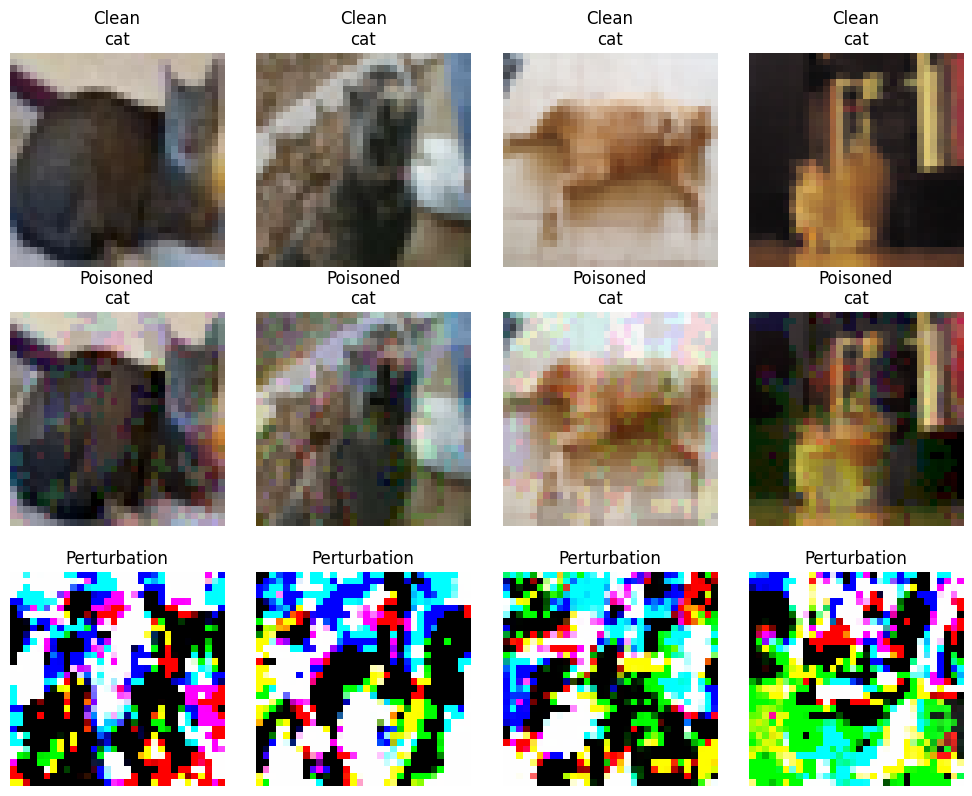

In [20]:
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(10, 8))
for col, idx in enumerate(poison_indices[:4]):
    axes[0, col].imshow(np.transpose(x_train[idx], (1, 2, 0)))
    axes[0, col].set_title(f'Clean\n{cifar10_class_labels[np.argmax(y_train[idx])]}')
    axes[1, col].imshow(np.transpose(x_poison[idx], (1, 2, 0)))
    axes[1, col].set_title(f'Poisoned\n{cifar10_class_labels[np.argmax(y_poison[idx])]}')
    delta = np.transpose(x_poison[idx] - x_train[idx], (1, 2, 0))
    axes[2, col].imshow((delta - delta.min()) / (np.ptp(delta) + 1e-12))
    axes[2, col].set_title('Perturbation')
    for row in range(3):
        axes[row, col].axis('off')

plt.tight_layout()
plt.show()

# Victim Model

In [21]:
victim_model = create_model()
victim = create_classifier(victim_model)

In [22]:
victim.fit(x_poison, y_poison, batch_size=128, nb_epochs=30, verbose=False)

# Results

In [23]:
victim_accuracy = np.mean(np.argmax(victim.predict(x_test), axis=1) == np.argmax(y_test, axis=1))
print("Clean Model Accuracy:", round(clean_accuracy, 4))
print("Victim Model Accuracy:", round(victim_accuracy, 4))
print("Accuracy Drop:", round(clean_accuracy - victim_accuracy, 4))

Clean Model Accuracy: 0.5821
Victim Model Accuracy: 0.5699
Accuracy Drop: 0.0122


In [24]:
trigger_predictions = np.argmax(victim.predict(x_trigger), axis=1)
print("Target Class:", cifar10_class_labels[CLASS_TARGET])
print("Victim Predictions:", [cifar10_class_labels[i] for i in trigger_predictions])
print("Attack Success Rate:", f"{np.mean(trigger_predictions == CLASS_TARGET):.1%}")

Target Class: cat
Victim Predictions: ['frog', 'cat', 'cat', 'cat', 'dog', 'dog', 'cat', 'cat', 'frog', 'cat']
Attack Success Rate: 60.0%


In [25]:
source_idx = np.where(np.argmax(y_test, axis=1) == CLASS_SOURCE)[0]
source_predictions = np.argmax(victim.predict(x_test[source_idx]), axis=1)
print("Other", cifar10_class_labels[CLASS_SOURCE], "images classified as", cifar10_class_labels[CLASS_TARGET] + ":", f"{np.mean(source_predictions == CLASS_TARGET):.1%}")

Other dog images classified as cat: 10.0%


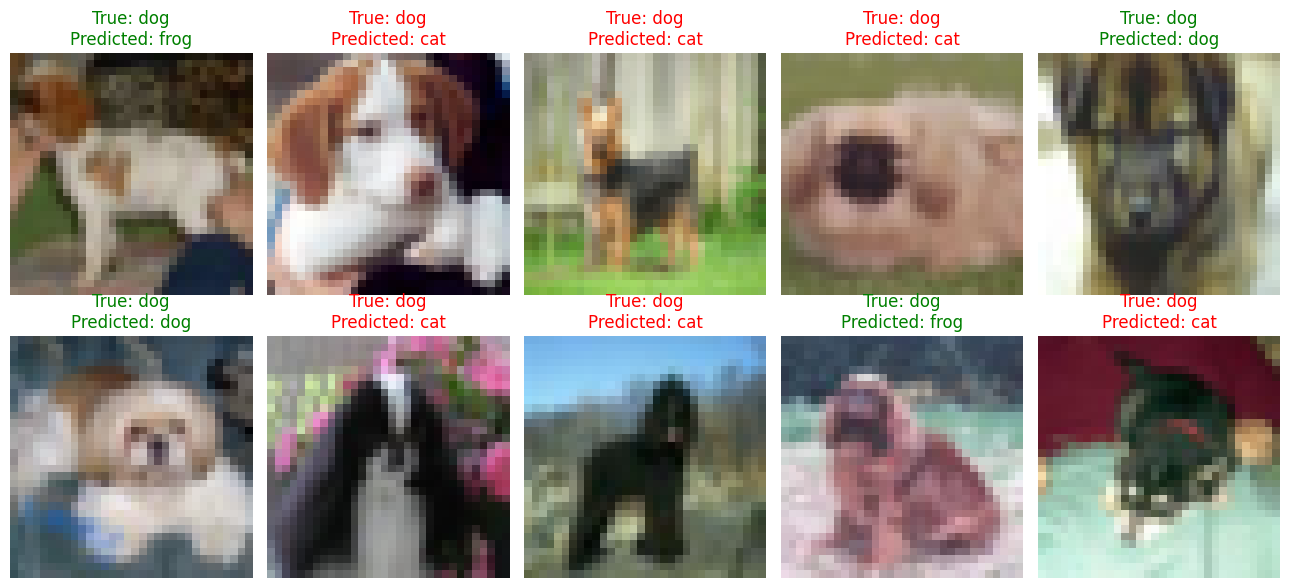

In [26]:
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(13, 6))
for ax, idx in zip(axes.ravel(), range(len(x_trigger))):
    ax.imshow(np.transpose(x_trigger[idx], (1, 2, 0)))
    ax.axis('off')
    prediction = trigger_predictions[idx]
    color = 'red' if prediction == CLASS_TARGET else 'green'
    ax.set_title(f'True: {cifar10_class_labels[CLASS_SOURCE]}\nPredicted: {cifar10_class_labels[prediction]}', color=color)

plt.tight_layout()
plt.show()